In [1]:
import os
import sys
import random

import torch
torch.set_float32_matmul_precision('medium')
import torch.nn as nn
import torch.optim as optim

import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import TensorBoardLogger, CSVLogger

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from PIL import Image
from torchvision import models, transforms
import torchvision.transforms as T

from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, r2_score, mean_absolute_error, mean_squared_error, precision_score, recall_score, f1_score, balanced_accuracy_score, top_k_accuracy_score

import tensorboard

sys.path.append('/home/jko/ice3d-ml-paper')
from models.mlp_regression import MLPRegression
from models.mlp_classification import MLPClassification
from models.resnet18_regression import ResNet18Regression
from models.resnet18_classification import ResNet18Classification
from models.cnn_regression import VanillaCNNRegression
from models.cnn_classification import VanillaCNNClassification

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
from data.tabular_datamodule import TabularDataModule
from data.tabular_dataset import TabularDataset
from data.single_view_datamodule import SingleViewDataModule
from data.single_view_dataset import SingleViewDataset
from data.stereo_view_datamodule import StereoViewDataModule
from data.stereo_view_dataset import StereoViewDataset
import json
from torchvision.models import ResNet18_Weights

import pickle
import joblib
from sklearn.preprocessing import StandardScaler

from pytorch_grad_cam import GuidedBackpropReLUModel
from pytorch_grad_cam import GradCAM, HiResCAM, LayerCAM, GradCAMPlusPlus, EigenGradCAM, GradCAMElementWise

XAI analysis on ResNet (or more generally, for convolutional NNs)

# Regression

In [2]:
# imagery
second_view = '2ds'
hdf_dir = '/home/jko/synth-ros-data/imgs-ml-ready/shuffled_small'
hdf_file1 = 'default_shuffled_small.h5'
hdf_file2 = f'{second_view}_shuffled_small.h5'
hdf_path1 = os.path.join(hdf_dir, hdf_file1)
hdf_path2 = os.path.join(hdf_dir, hdf_file2)
# tabular
tab_dir = '/home/jko/synth-ros-data/tabular-data-v2/shuffled_small'
tab_file = 'ros-tabular-data-shuffled-default-subset-700000.parquet'
tab_path = os.path.join(tab_dir, tab_file)
tab_stereo_2ds_file = 'ros-tabular-data-stereo-default-2ds-shuffled-subset-700000.parquet'
tab_stereo_2ds_path = os.path.join(tab_dir, tab_stereo_2ds_file)
tab_stereo_phips_file = 'ros-tabular-data-stereo-default-phips-shuffled-subset-700000.parquet'
tab_stereo_phips_path = os.path.join(tab_dir, tab_stereo_phips_file)
# Load the class mapping from a JSON file
class_mapping_file = '/home/jko/ice3d/data/class_to_idx.json'
# where to save plots
savedir = './figs/test-results'
os.makedirs(savedir, exist_ok=True)
# Load class mapping from JSON file
with open(class_mapping_file, 'r') as f:
    class_to_idx = json.load(f)
num_classes = len(class_to_idx)  # Number of unique classes in n_arms

# set up data
features_default = ['aspect_ratio', 'aspect_ratio_elip', 
'extreme_pts', 'contour_area', 'contour_perimeter', 
'area_ratio', 'complexity', 'circularity']
features_stereo = ['aspect_ratio_1', 'aspect_ratio_elip_1', 
'extreme_pts_1', 'contour_area_1', 'contour_perimeter_1', 
'area_ratio_1', 'complexity_1', 'circularity_1',
'aspect_ratio_2', 'aspect_ratio_elip_2', 'extreme_pts_2', 
'contour_area_2', 'contour_perimeter_2', 'area_ratio_2', 
'complexity_2', 'circularity_2']
targets_reg = ['rho_eff', 'sa_eff']
targets_cls = ['n_arms']
batch_size = 128
n_rand = 666
num_workers = 16
def log_transform(x):
    return torch.log(x)
split = [0.7, 0.15, 0.15]
n_data = 700_000
assert abs(sum(split) - 1.0) < 1e-8, "Split does not sum to 1"
n_train = int(split[0] * n_data)
n_val = int(split[1] * n_data)
n_test = n_data - n_train - n_val  # ensures all data is used
train_idx = list(range(0, n_train))
val_idx = list(range(n_train, n_train + n_val))
test_idx = list(range(n_train + n_val, n_data))

# set colors
cmap_reg = 'magma'
cmap_cls = 'Blues'

# global plot parameters 
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['font.size'] = 14

# define transforms
def get_transforms(data_type, input_channels, task_type):
    transforms = {}
    # Define transforms based on data_type
    if data_type in ['single_view_h5', 'stereo_view_h5']:
        train_transform = T.Compose([
                T.RandomHorizontalFlip(),
                T.RandomVerticalFlip(),
                T.Normalize(mean=[0.5] * input_channels, std=[1.0] * input_channels)
            ])
        val_transform = T.Compose([
                T.Normalize(mean=[0.5] * input_channels, std=[1.0] * input_channels)
            ])
        transforms['train'] = train_transform
        transforms['val'] = val_transform
        transforms['test'] = val_transform
        # define target transform
        if task_type == 'classification':
            target_transform = None
        else:
            def log_transform(x):
                return torch.log(x)
            target_transform = log_transform
        transforms['train_target'] = target_transform
        transforms['val_target'] = target_transform
        transforms['test_target'] = target_transform    
        return transforms
    elif data_type == 'tabular':
        # define target transform
        if task_type == 'classification':
            target_transform = None
        else:
            def log_transform(x):
                return torch.log(x)
            target_transform = log_transform
        transforms['target'] = target_transform
        return transforms
    else:
        return None

# create dataframe to save metrics for all models
metrics_reg = {}
metrics_cls = {}

In [3]:
# ---------------------------
# Load data + model (your code)
# ---------------------------
# Assumes these symbols exist in your project:
# - get_transforms, SingleViewDataModule, ResNet18Regression
# - targets_reg, train_idx, val_idx, test_idx, batch_size, n_rand

second_view = '2ds'
hdf_dir = '/home/jko/synth-ros-data/imgs-ml-ready/shuffled_small'
hdf_file1 = 'default_shuffled_small.h5'
hdf_file2 = f'{second_view}_shuffled_small.h5'
hdf_path1 = os.path.join(hdf_dir, hdf_file1)
hdf_path2 = os.path.join(hdf_dir, hdf_file2)

data_type = 'single_view_h5'
input_channels = 1
task_type = 'regression'
transforms = get_transforms(data_type, input_channels, task_type)

dm = SingleViewDataModule(
    hdf_file=hdf_path1,
    target_names=targets_reg,   # e.g., ['rho_eff', 'sa_eff']
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
    batch_size=batch_size,
    subset_size=None,
    subset_seed=n_rand,
    num_workers=16,
    prefetch_factor=16,
    train_transform=transforms['train'],
    val_transform=transforms['val'],
    test_transform=transforms['test'],
    train_target_transform=transforms['train_target'],
    val_target_transform=transforms['val_target'],
    test_target_transform=transforms['test_target'],
    task_type='regression',
    class_to_idx=None
)
dm.setup()

model_ckpt = '/home/jko/ice3d/models/lightning_logs/resnet18-regression-subset-700k-csv/version_3/checkpoints/model-epoch=49-val_loss=0.0039.ckpt'
model = ResNet18Regression.load_from_checkpoint(
    checkpoint_path=model_ckpt,
    input_channels=1,
    output_size=2,
    learning_rate=1e-3,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [4]:
import os
import torch
import numpy as np
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from torch import nn
import cv2 as cv

In [5]:
# Your provided target class
class RegressionOutputTarget:
    """
    Target for single output of a regression model.
    Args:
        output_index (int): which output to target (0 or 1 for two outputs)
    """
    def __init__(self, output_index):
        self.output_index = output_index

    def __call__(self, model_output):
        # model_output: shape (2,) or (batch, 2)
        if model_output.ndim == 1:
            return model_output[self.output_index]
        return model_output[:, self.output_index]

def find_last_conv_layer(model: nn.Module) -> nn.Module:
    last = None
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            last = m
    if last is None:
        raise RuntimeError("No Conv2d layers found in model.")
    return last

def to_rgb_image(x: torch.Tensor) -> np.ndarray:
    """
    x: (C,H,W) tensor on CPU. Returns float32 RGB in [0,1], shape (H,W,3).
    """
    x = x.float()
    # Per-image min-max to [0,1] for visualization
    vmin = torch.amin(x)
    vmax = torch.amax(x)
    x01 = (x - vmin) / (vmax - vmin + 1e-8)

    if x01.shape[0] == 1:
        img = x01[0].cpu().numpy()
        rgb = np.stack([img, img, img], axis=-1).astype(np.float32)
    elif x01.shape[0] >= 3:
        # Use first 3 channels
        rgb = x01[:3].permute(1, 2, 0).cpu().numpy().astype(np.float32)
    else:
        # If C=2, pad to 3
        pad = torch.zeros((3 - x01.shape[0], *x01.shape[1:]), dtype=x01.dtype, device=x01.device)
        rgb = torch.cat([x01, pad], dim=0).permute(1, 2, 0).cpu().numpy().astype(np.float32)
    return rgb

def deprocess_image(img, strategy="minmax"):
    # img: HWC float, arbitrary range (e.g., tiny +/- values)
    img = np.asarray(img, dtype=np.float32)

    if strategy == "minmax":
        vmin = float(img.min())
        vmax = float(img.max())
        if vmax > vmin:
            img = (img - vmin) / (vmax - vmin + 1e-12)  # -> [0,1]
        else:
            img = np.zeros_like(img, dtype=np.float32)
    elif strategy == "absmax":
        amax = float(np.max(np.abs(img)))
        if amax > 0:
            img = img / (amax + 1e-12)  # -> [-1,1]
            img = (img + 1.0) / 2.0     # -> [0,1]
        else:
            img = np.zeros_like(img, dtype=np.float32)
    else:
        # Fallback if you already know it's in [0,1] or [-1,1]
        if img.min() < 0:
            img = (img + 1.0) / 2.0
        img = np.clip(img, 0, 1)

    img = np.clip(img, 0, 1)
    return (img * 255.0).astype(np.uint8)

def normalize_cam(cam):
    cam = cam.astype(np.float32)
    vmin, vmax = float(cam.min()), float(cam.max())
    if vmax > vmin:
        cam = (cam - vmin) / (vmax - vmin + 1e-12)
    else:
        cam = np.zeros_like(cam, dtype=np.float32)
    return cam

def colorize_cam(cam01, colormap=cv.COLORMAP_JET):
    # cam01: (H,W) in [0,1]
    cam_uint8 = (cam01 * 255).astype(np.uint8)
    cam_color = cv.applyColorMap(cam_uint8, colormap)      # BGR uint8
    cam_color = cv.cvtColor(cam_color, cv.COLOR_BGR2RGB)   # to RGB
    return cam_color

def overlay_cam_on_image(img_rgb01, cam, alpha=0.5, resize_to_img=True):
    """
    img_rgb01: HWC RGB float in [0,1]
    cam: 2D float CAM (Hc,Wc), any range
    alpha: overlay strength (0..1)
    """
    h, w = img_rgb01.shape[:2]
    cam01 = normalize_cam(cam)
    if resize_to_img and cam01.shape != (h, w):
        cam01 = cv.resize(cam01, (w, h), interpolation=cv.INTER_LINEAR)
    cam_color = colorize_cam(cam01)                        # RGB uint8
    img_u8 = (np.clip(img_rgb01, 0, 1) * 255).astype(np.uint8)
    overlay = cv.addWeighted(img_u8, 1 - alpha, cam_color, alpha, 0.0)  # RGB uint8
    return overlay

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).eval()

target_layer = find_last_conv_layer(model)
test_loader = dm.test_dataloader()

out_dir = '/home/jko/ice3d-ml-paper/out/xai_outputs/pytorch_grad_cam'
os.makedirs(out_dir, exist_ok=True)
output_indices = [0, 1]

In [7]:
# GradCam with optional guided backprop
use_guided_backprop = True  # Set to False to disable guided backprop
max_batches = 1  # e.g., 5; set to None to process all

# cam_method = 'hires', 'layer', 'plusplus', 'eigen', or 'elem'
cam_method = 'GradCAM'  # 'hires', 'layer', or 'elem'

if cam_method == 'hires':
    CAM = HiResCAM
elif cam_method == 'layer':
    CAM = LayerCAM
elif cam_method == 'plusplus':
    CAM = GradCAMPlusPlus
elif cam_method == 'eigen':
    CAM = EigenGradCAM
elif cam_method == 'GradCAM':
    CAM = GradCAM
else:
    CAM = GradCAMElementWise

save_dir = os.path.join(out_dir, f'{cam_method}_guided_bp' if use_guided_backprop else f'{cam_method}_cam_only')
os.makedirs(save_dir, exist_ok=True)
print(save_dir)

input_mean = 0.5
input_std = 1.0

if use_guided_backprop:
    try:
        gb_model = GuidedBackpropReLUModel(model=model, device=device)
    except TypeError:
        gb_model = GuidedBackpropReLUModel(model=model, use_cuda=(device.type == "cuda"))

# helper to normalize gb output to shape (C, H, W) numpy
def gb_to_chw(gb):
    # gb can be torch.Tensor or numpy array with shapes like:
    # (1,C,H,W), (C,H,W), (H,W,C), (H,W,1), (H,W)
    if isinstance(gb, torch.Tensor):
        gb = gb.detach().cpu().numpy()
    gb = np.array(gb)
    if gb.ndim == 4 and gb.shape[0] == 1:
        gb = gb[0]           # (C,H,W) or (H,W,C)
    if gb.ndim == 3 and gb.shape[2] in (1,3) and gb.shape[0] not in (1,3):
        # HWC -> CHW
        gb = np.transpose(gb, (2, 0, 1))
    if gb.ndim == 2:
        gb = gb[None, ...]   # (1, H, W)
    if gb.ndim == 3 and gb.shape[0] in (1,3):
        return gb.astype(np.float32)
    raise ValueError(f"Unhandled guided-backprop shape: {gb.shape}")

with CAM(model=model, target_layers=[target_layer]) as cam:
    for batch_idx, (xb, yb) in enumerate(test_loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        xb = xb.to(device, non_blocking=True)

        with torch.no_grad():
            preds = model(xb).detach().cpu().numpy()

        for out_ix in output_indices:
            targets = [RegressionOutputTarget(out_ix) for _ in range(xb.size(0))]
            grayscale_cams = cam(input_tensor=xb, targets=targets, aug_smooth=False, eigen_smooth=False)

            for i in range(xb.shape[0]):
                img_rgb = to_rgb_image(xb[i].detach().cpu())     # HWC float [0,1]
                cam_map = grayscale_cams[i]                      # (H, W) float32
                # Debug: Check CAM output range
                print("cam_map min/max:", cam_map.min(), cam_map.max())

                if use_guided_backprop:
                    inp = xb[i : i + 1].clone().detach().requires_grad_(True).to(device)
                    gb_raw = gb_model(inp, target_category=out_ix)
                    try:
                        gb_chw = gb_to_chw(gb_raw)
                    except ValueError:
                        gb_np = gb_raw.detach().cpu().numpy() if isinstance(gb_raw, torch.Tensor) else np.array(gb_raw)
                        if gb_np.ndim == 3 and gb_np.shape[2] in (1,):
                            gb_np = np.transpose(gb_np, (2, 0, 1))  # (1,H,W)
                        gb_chw = gb_to_chw(gb_np)
                    # Debug: Check guided backprop output range
                    print("gb_chw min/max:", gb_chw.min(), gb_chw.max())

                    C, Hg, Wg = gb_chw.shape
                    if cam_map.shape != (Hg, Wg):
                        cam_resized = cv.resize(cam_map, (Wg, Hg), interpolation=cv.INTER_LINEAR)
                    else:
                        cam_resized = cam_map

                    prod = gb_chw * cam_resized[None, :, :]
                    prod_hwc = np.transpose(prod, (1, 2, 0))
                    if prod_hwc.shape[2] == 1:
                        prod_hwc = np.repeat(prod_hwc, 3, axis=2)

                    # Debug: Check product output range
                    print("prod_hwc min/max:", prod_hwc.min(), prod_hwc.max())

                    guided_gc = deprocess_image(prod_hwc, strategy='minmax')  # uint8 HWC
                    pred_str = "_".join([f"{p:.4f}" for p in np.atleast_1d(preds[i])])
                    base_name = f"batch{batch_idx:04d}_idx{i:02d}_out{out_ix}_pred_{pred_str}_cam_gb.png"
                    cam_gb_path = os.path.join(save_dir, base_name)

                    print(cam_gb_path)
                    cv.imwrite(cam_gb_path, guided_gc[:, :, ::-1])   # RGB->BGR for OpenCV
                else:
                    # # Save only the CAM
                    # cam_img = deprocess_image(np.repeat(cam_map[:, :, None], 3, axis=2), strategy='minmax')  # HWC
                    # pred_str = "_".join([f"{p:.4f}" for p in np.atleast_1d(preds[i])])
                    # base_name = f"batch{batch_idx:04d}_idx{i:02d}_out{out_ix}_pred_{pred_str}_cam.png"
                    # cam_path = os.path.join(save_dir, base_name)
                    # print(cam_path)
                    # cv.imwrite(cam_path, cam_img[:, :, ::-1])   # RGB->BGR for OpenCV

                    # Save only the CAM as an overlay on the original image
                    # 1) Ensure img_rgb is in [0,1] float and matches expected H,W
                    #    (your to_rgb_image returns float [0,1] HWC)
                    overlay = overlay_cam_on_image(img_rgb, cam_map, alpha=0.5)

                    pred_str = "_".join([f"{p:.4f}" for p in np.atleast_1d(preds[i])])
                    base_name = f"batch{batch_idx:04d}_idx{i:02d}_out{out_ix}_pred_{pred_str}_cam_overlay.png"
                    cam_path = os.path.join(save_dir, base_name)
                    print(cam_path)

                    # Convert RGB->BGR for OpenCV write
                    cv.imwrite(cam_path, overlay[:, :, ::-1])

print(f"Saved CAMs to: {os.path.abspath(save_dir)}")

/home/jko/ice3d-ml-paper/out/xai_outputs/pytorch_grad_cam/GradCAM_guided_bp
cam_map min/max: 0.0 0.9999999
gb_chw min/max: -0.00030652658 0.0002895561
prod_hwc min/max: -0.00022025309 0.00021031177
/home/jko/ice3d-ml-paper/out/xai_outputs/pytorch_grad_cam/GradCAM_guided_bp/batch0000_idx00_out0_pred_-4.0799_-1.7594_cam_gb.png
cam_map min/max: 0.0 0.9999999
gb_chw min/max: -0.00015925488 0.000191033
prod_hwc min/max: -9.53747e-05 0.000118200696
/home/jko/ice3d-ml-paper/out/xai_outputs/pytorch_grad_cam/GradCAM_guided_bp/batch0000_idx01_out0_pred_-2.8493_-1.2098_cam_gb.png
cam_map min/max: 0.0 0.9999999
gb_chw min/max: -5.5709155e-05 6.586951e-05
prod_hwc min/max: -5.5343902e-05 6.488956e-05
/home/jko/ice3d-ml-paper/out/xai_outputs/pytorch_grad_cam/GradCAM_guided_bp/batch0000_idx02_out0_pred_-3.3693_-1.3721_cam_gb.png
cam_map min/max: 0.0 0.9999999
gb_chw min/max: -0.0001158161 0.00014392962
prod_hwc min/max: -9.1171656e-05 0.00012280638
/home/jko/ice3d-ml-paper/out/xai_outputs/pytorch_gra

# Classification

In [32]:
# load data module
second_view = '2ds'
hdf_dir = '/home/jko/synth-ros-data/imgs-ml-ready/shuffled_small'
hdf_file1 = 'default_shuffled_small.h5'
hdf_file2 = f'{second_view}_shuffled_small.h5'
hdf_path1 = os.path.join(hdf_dir, hdf_file1)
hdf_path2 = os.path.join(hdf_dir, hdf_file2)
data_type = 'single_view_h5'
input_channels = 1
task_type = 'classification'
transforms = get_transforms(data_type, input_channels, task_type)
dm = SingleViewDataModule(
    hdf_file=hdf_path1,
    target_names=targets_cls,
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
    batch_size=batch_size,
    subset_size=None,
    subset_seed=n_rand,
    num_workers=16,
    prefetch_factor=16,
    train_transform=transforms['train'],
    val_transform=transforms['val'],
    test_transform=transforms['test'],
    train_target_transform=transforms['train_target'],
    val_target_transform=transforms['val_target'],
    test_target_transform=transforms['test_target'],
    task_type='classification',
    class_to_idx=class_to_idx
)
dm.setup()

model_ckpt = '/home/jko/ice3d/models/lightning_logs/resnet18-classification-subset-700k-csv/version_1/checkpoints/model-epoch=32-val_loss=0.2860.ckpt'
model = ResNet18Classification.load_from_checkpoint(
    checkpoint_path=model_ckpt,
    input_channels=1, 
    num_classes=7, 
    learning_rate=1e-3, 
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

/home/jko/miniconda3/envs/torch/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet18Classification(
  (resnet18): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine

In [44]:
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

target_layer = find_last_conv_layer(model)
test_loader = dm.test_dataloader()  # expects your DataModule 'dm' to be ready

# Choose class target mode: "pred" (argmax), "gt" (ground truth), or "fixed"
target_mode = "pred"
fixed_class = 0  # used only when target_mode == "fixed"

use_guided_backprop = True    # set False for CAM overlay only
max_batches = 1               # None to process all

# Map method name to CAM class (includes synonyms)
cam_method = "plusplus"  # "hires" | "layer" | "plusplus" | "eigen" | "gradcam" | "elem" | "elementwise"
method_map = {
    "hires": HiResCAM,
    "layer": LayerCAM,
    "plusplus": GradCAMPlusPlus,
    "eigen": EigenGradCAM,
    "gradcam": GradCAM,
    "elem": GradCAMElementWise,
    "elementwise": GradCAMElementWise,
}
CAM = method_map.get(cam_method.lower(), GradCAMElementWise)

out_dir = "/home/jko/ice3d-ml-paper/out/xai_outputs/pytorch_grad_cam"
save_dir = os.path.join(out_dir, f"{cam_method}_guided_bp_cls" if use_guided_backprop else f"{cam_method}_cam_only_cls")
os.makedirs(save_dir, exist_ok=True)
print(save_dir)

# Optional Guided-BP model
if use_guided_backprop:
    try:
        gb_model = GuidedBackpropReLUModel(model=model, device=device)
    except TypeError:
        gb_model = GuidedBackpropReLUModel(model=model, use_cuda=(device.type == "cuda"))

# ---------- Grad-CAM ----------
with CAM(model=model, target_layers=[target_layer]) as cam:
    for batch_idx, (xb, yb) in enumerate(test_loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        xb = xb.to(device, non_blocking=True)

        # Use logits (pre-softmax) for stable gradients
        with torch.no_grad():
            logits = model(xb)                  # shape (B, 7)
            preds_np = logits.detach().cpu().numpy()

        # Per-sample target class
        if target_mode == "pred":
            target_indices = np.argmax(preds_np, axis=1).astype(int)
        elif target_mode == "gt":
            target_indices = yb.detach().cpu().numpy().astype(int)
        else:
            target_indices = np.full(xb.size(0), int(fixed_class), dtype=int)

        targets = [ClassifierOutputTarget(int(target_indices[j])) for j in range(xb.size(0))]

        grayscale_cams = cam(
            input_tensor=xb,
            targets=targets,
            aug_smooth=False,
            eigen_smooth=False
        )

        for i in range(xb.shape[0]):
            img_rgb = to_rgb_image(xb[i].detach().cpu())   # HWC float [0,1]
            cam_map = grayscale_cams[i]                    # (H, W) float32
            cls_id = int(target_indices[i])

            if use_guided_backprop:
                inp = xb[i:i+1].clone().detach().requires_grad_(True).to(device)
                gb_raw = gb_model(inp, target_category=cls_id)  # single class index
                try:
                    gb_chw = gb_to_chw(gb_raw)
                except ValueError:
                    gb_np = gb_raw.detach().cpu().numpy() if isinstance(gb_raw, torch.Tensor) else np.array(gb_raw)
                    if gb_np.ndim == 3 and gb_np.shape[2] in (1,):
                        gb_np = np.transpose(gb_np, (2, 0, 1))
                    gb_chw = gb_to_chw(gb_np)

                C, Hg, Wg = gb_chw.shape
                cam_resized = cam_map if cam_map.shape == (Hg, Wg) else cv.resize(cam_map, (Wg, Hg), interpolation=cv.INTER_LINEAR)
                prod = gb_chw * cam_resized[None, :, :]
                prod_hwc = np.transpose(prod, (1, 2, 0))
                if prod_hwc.shape[2] == 1:
                    prod_hwc = np.repeat(prod_hwc, 3, axis=2)

                guided_gc = deprocess_image(prod_hwc, strategy="minmax")  # uint8 HWC (RGB)
                pred_str = "_".join([f"{p:.4f}" for p in np.atleast_1d(preds_np[i])])
                base_name = f"batch{batch_idx:04d}_idx{i:02d}_cls{cls_id}_pred_{pred_str}_cam_gb.png"
                out_path = os.path.join(save_dir, base_name)
                print(out_path)
                cv.imwrite(out_path, guided_gc[:, :, ::-1])  # RGB -> BGR for write
            else:
                overlay = overlay_cam_on_image(img_rgb, cam_map, alpha=0.5)  # RGB uint8
                pred_str = "_".join([f"{p:.4f}" for p in np.atleast_1d(preds_np[i])])
                base_name = f"batch{batch_idx:04d}_idx{i:02d}_cls{cls_id}_pred_{pred_str}_cam_overlay.png"
                out_path = os.path.join(save_dir, base_name)
                print(out_path)
                cv.imwrite(out_path, overlay[:, :, ::-1])     # RGB -> BGR

/home/jko/ice3d-ml-paper/out/xai_outputs/pytorch_grad_cam/plusplus_guided_bp_cls
/home/jko/ice3d-ml-paper/out/xai_outputs/pytorch_grad_cam/plusplus_guided_bp_cls/batch0000_idx00_cls1_pred_-14.5487_7.1373_-0.6286_-3.8091_-9.2826_-12.0599_-17.3002_cam_gb.png
/home/jko/ice3d-ml-paper/out/xai_outputs/pytorch_grad_cam/plusplus_guided_bp_cls/batch0000_idx01_cls0_pred_15.9584_10.2005_-4.4703_-12.7212_-20.0639_-30.9977_-39.6937_cam_gb.png
/home/jko/ice3d-ml-paper/out/xai_outputs/pytorch_grad_cam/plusplus_guided_bp_cls/batch0000_idx02_cls1_pred_-6.9027_7.2289_0.9749_-2.3651_-10.3971_-16.9530_-22.2007_cam_gb.png
/home/jko/ice3d-ml-paper/out/xai_outputs/pytorch_grad_cam/plusplus_guided_bp_cls/batch0000_idx03_cls0_pred_19.4566_9.9486_-15.2520_-20.3942_-28.0587_-38.2848_-50.9095_cam_gb.png
/home/jko/ice3d-ml-paper/out/xai_outputs/pytorch_grad_cam/plusplus_guided_bp_cls/batch0000_idx04_cls1_pred_0.6196_11.8632_2.5538_-7.6720_-20.1770_-28.8284_-35.0441_cam_gb.png
/home/jko/ice3d-ml-paper/out/xai_outp

In [41]:
model.layer3[-1]   # finer than layer4

AttributeError: 'ResNet18Classification' object has no attribute 'layer3'

In [42]:
def get_resnet_target_layer(model: nn.Module, stage="layer4"):
    """Use a specific stage if present, else fallback to last conv in whole model."""
    stage_mod, stage_name = find_stage_anywhere(model, (stage,))
    if stage_mod is not None:
        return find_last_conv_layer(stage_mod)  # last conv inside that stage
    return find_last_conv_layer(model)

get_resnet_target_layer(model, stage="layer3")

Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)

In [43]:
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def get_resnet_target_layer(model: nn.Module, stage="layer4"):
    """Use a specific stage if present, else fallback to last conv in whole model."""
    stage_mod, stage_name = find_stage_anywhere(model, (stage,))
    if stage_mod is not None:
        return find_last_conv_layer(stage_mod)  # last conv inside that stage
    return find_last_conv_layer(model)


test_loader = dm.test_dataloader()  # expects your DataModule 'dm' to be ready

# Choose class target mode: "pred" (argmax), "gt" (ground truth), or "fixed"
target_mode = "pred"
fixed_class = 0  # used only when target_mode == "fixed"

use_guided_backprop = False    # set False for CAM overlay only
max_batches = 1               # None to process all

# Map method name to CAM class (includes synonyms)
cam_method = "gradcam"  # "hires" | "layer" | "plusplus" | "eigen" | "gradcam" | "elem" | "elementwise"
method_map = {
    "hires": HiResCAM,
    "layer": LayerCAM,
    "plusplus": GradCAMPlusPlus,
    "eigen": EigenGradCAM,
    "gradcam": GradCAM,
    "elem": GradCAMElementWise,
    "elementwise": GradCAMElementWise,
}
CAM = method_map.get(cam_method.lower(), GradCAMElementWise)

out_dir = "/home/jko/ice3d-ml-paper/out/xai_outputs/pytorch_grad_cam"
# save_dir = os.path.join(out_dir, f"{cam_method}_guided_bp_cls" if use_guided_backprop else f"{cam_method}_cam_only_cls")
# os.makedirs(save_dir, exist_ok=True)
# print(save_dir)

# Optional Guided-BP model
if use_guided_backprop:
    try:
        gb_model = GuidedBackpropReLUModel(model=model, device=device)
    except TypeError:
        gb_model = GuidedBackpropReLUModel(model=model, use_cuda=(device.type == "cuda"))

# Try on earlier layer
layers_to_try = ["layer4", "layer3", "layer2"]  # ordered coarse -> fine

for which in layers_to_try:
    # submod = getattr(model, which) if hasattr(model, which) else model
    # target_layer = find_last_conv_layer(submod)
    target_layer = get_resnet_target_layer(model, stage=which)

    layer_tag = which
    save_dir = os.path.join(
        out_dir,
        f"{cam_method}_{layer_tag}_" + ("guided_bp_cls" if use_guided_backprop else "cam_only_cls")
    )
    os.makedirs(save_dir, exist_ok=True)
    print("Saving to:", save_dir)

    with CAM(model=model, target_layers=[target_layer]) as cam:
        for batch_idx, (xb, yb) in enumerate(test_loader):
            if max_batches is not None and batch_idx >= max_batches:
                break

            xb = xb.to(device, non_blocking=True)
            with torch.no_grad():
                logits = model(xb)
                preds_np = logits.detach().cpu().numpy()

            if target_mode == "pred":
                target_indices = np.argmax(preds_np, axis=1).astype(int)
            elif target_mode == "gt":
                target_indices = yb.detach().cpu().numpy().astype(int)
            else:
                target_indices = np.full(xb.size(0), int(fixed_class), dtype=int)

            targets = [ClassifierOutputTarget(int(target_indices[j])) for j in range(xb.size(0))]
            grayscale_cams = cam(input_tensor=xb, targets=targets, aug_smooth=False, eigen_smooth=False)

            for i in range(xb.shape[0]):
                img_rgb = to_rgb_image(xb[i].detach().cpu())
                cam_map = grayscale_cams[i]
                cls_id = int(target_indices[i])

                if use_guided_backprop:
                    inp = xb[i:i+1].clone().detach().requires_grad_(True).to(device)
                    gb_raw = gb_model(inp, target_category=cls_id)
                    try:
                        gb_chw = gb_to_chw(gb_raw)
                    except ValueError:
                        gb_np = gb_raw.detach().cpu().numpy() if isinstance(gb_raw, torch.Tensor) else np.array(gb_raw)
                        if gb_np.ndim == 3 and gb_np.shape[2] in (1,):
                            gb_np = np.transpose(gb_np, (2, 0, 1))
                        gb_chw = gb_to_chw(gb_np)

                    C, Hg, Wg = gb_chw.shape
                    cam_resized = cam_map if cam_map.shape == (Hg, Wg) else cv.resize(cam_map, (Wg, Hg), interpolation=cv.INTER_LINEAR)
                    prod = gb_chw * cam_resized[None, :, :]
                    prod_hwc = np.transpose(prod, (1, 2, 0))
                    if prod_hwc.shape[2] == 1:
                        prod_hwc = np.repeat(prod_hwc, 3, axis=2)

                    guided_gc = deprocess_image(prod_hwc, strategy="minmax")
                    pred_str = "_".join([f"{p:.4f}" for p in np.atleast_1d(preds_np[i])])
                    base_name = f"batch{batch_idx:04d}_idx{i:02d}_cls{cls_id}_{layer_tag}_pred_{pred_str}_cam_gb.png"
                    out_path = os.path.join(save_dir, base_name)
                    print(out_path)
                    cv.imwrite(out_path, guided_gc[:, :, ::-1])
                else:
                    overlay = overlay_cam_on_image(img_rgb, cam_map, alpha=0.5)
                    pred_str = "_".join([f"{p:.4f}" for p in np.atleast_1d(preds_np[i])])
                    base_name = f"batch{batch_idx:04d}_idx{i:02d}_cls{cls_id}_{layer_tag}_pred_{pred_str}_cam_overlay.png"
                    out_path = os.path.join(save_dir, base_name)
                    print(out_path)
                    cv.imwrite(out_path, overlay[:, :, ::-1])

Saving to: /home/jko/ice3d-ml-paper/out/xai_outputs/pytorch_grad_cam/gradcam_layer4_cam_only_cls
/home/jko/ice3d-ml-paper/out/xai_outputs/pytorch_grad_cam/gradcam_layer4_cam_only_cls/batch0000_idx00_cls1_layer4_pred_-14.5487_7.1373_-0.6286_-3.8091_-9.2826_-12.0599_-17.3002_cam_overlay.png
/home/jko/ice3d-ml-paper/out/xai_outputs/pytorch_grad_cam/gradcam_layer4_cam_only_cls/batch0000_idx01_cls0_layer4_pred_15.9584_10.2005_-4.4703_-12.7212_-20.0639_-30.9977_-39.6937_cam_overlay.png
/home/jko/ice3d-ml-paper/out/xai_outputs/pytorch_grad_cam/gradcam_layer4_cam_only_cls/batch0000_idx02_cls1_layer4_pred_-6.9027_7.2289_0.9749_-2.3651_-10.3971_-16.9530_-22.2007_cam_overlay.png
/home/jko/ice3d-ml-paper/out/xai_outputs/pytorch_grad_cam/gradcam_layer4_cam_only_cls/batch0000_idx03_cls0_layer4_pred_19.4566_9.9486_-15.2520_-20.3942_-28.0587_-38.2848_-50.9095_cam_overlay.png
/home/jko/ice3d-ml-paper/out/xai_outputs/pytorch_grad_cam/gradcam_layer4_cam_only_cls/batch0000_idx04_cls1_layer4_pred_0.6196_11

# Visualize

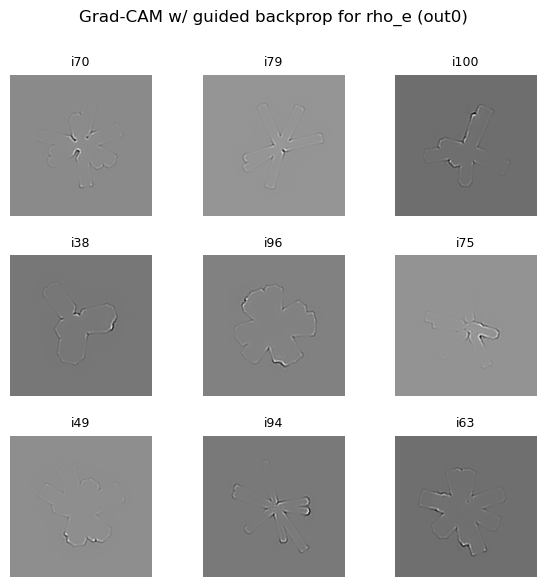

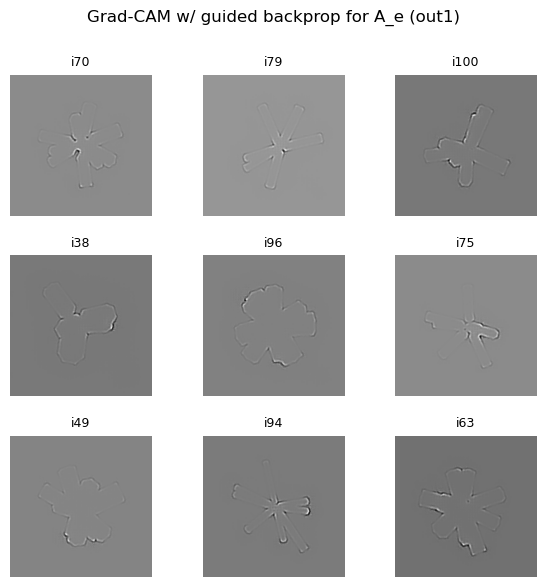

In [20]:
import os, glob, random, math, re
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Directory with saved overlays
cam_outdir = '/home/jko/ice3d-ml-paper/out/xai_outputs/pytorch_grad_cam/GradCAM_guided_bp'

# Prefer files ending with cam_gb.png; fall back to any .png if none found
patterns = [
    os.path.join(cam_outdir, "batch*_idx*_out*_pred_*_cam_gb.png"),
    os.path.join(cam_outdir, "batch*_idx*_out*_pred_*.png"),
]

paths = []
for p in patterns:
    paths = glob.glob(p)
    if paths:
        break
paths = sorted(paths)
if not paths:
    raise FileNotFoundError(f"No overlays found in {cam_outdir}")

# Parse filename metadata robustly
rx = re.compile(r"batch(\d+)_idx(\d+)_out(\d+)_pred_([-\d.eE]+)_([-\d.eE]+)")
def parse_meta(path):
    m = rx.search(os.path.basename(path))
    if not m:
        return None
    b, i, o, p0, p1 = m.groups()
    return {
        "batch": int(b),
        "idx": int(i),
        "out": int(o),
        "preds": [float(p0), float(p1)],
    }

# Group by (batch, idx) and keep paths for out0 and out1
by_pair = {}  # (batch, idx) -> {0: path, 1: path}
for p in paths:
    meta = parse_meta(p)
    if not meta:
        continue
    key = (meta["batch"], meta["idx"])
    by_pair.setdefault(key, {})
    by_pair[key][meta["out"]] = p

# Only keep pairs that have both outs
pairs = [k for k, v in by_pair.items() if 0 in v and 1 in v]
if not pairs:
    raise RuntimeError("No (batch, idx) pairs with both out0 and out1.")
random.seed(0)
pairs = random.sample(pairs, k=min(9, len(pairs)))

head_names = {0: "rho_e", 1: "A_e"}

def plot_grid(head_idx, pairs, savepath=None, show=True, dpi=200):
    k = len(pairs)
    cols = 3
    rows = math.ceil(k / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(2.0*cols, 2.0*rows))
    axes = np.array(axes).reshape(-1)

    for ax, (b, i) in zip(axes, pairs):
        path = by_pair[(b, i)][head_idx]
        with Image.open(path) as im:
            img = np.asarray(im.convert("RGB"))

        # Only show the index label for each subplot
        ax.imshow(img)
        ax.set_title(f"i{i:02d}", fontsize=9)
        ax.axis("off")

    for ax in axes[k:]:
        ax.axis("off")

    fig.suptitle(f"Grad-CAM w/ guided backprop for {head_names[head_idx]} (out{head_idx})", fontsize=12)
    plt.tight_layout()

    if savepath:
        os.makedirs(os.path.dirname(savepath) or ".", exist_ok=True)
        fig.savefig(savepath, dpi=dpi, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)

# Save examples (adjust paths as needed)
plot_dir = '/home/jko/ice3d-ml-paper/figs/gradcam'
os.makedirs(plot_dir, exist_ok=True)
savepath1 = os.path.join(plot_dir, "gradcam_grid_rho_e.png")
savepath2 = os.path.join(plot_dir, "gradcam_grid_A_e.png")
plot_grid(0, pairs, savepath1, dpi=300)
plot_grid(1, pairs, savepath2, dpi=300)

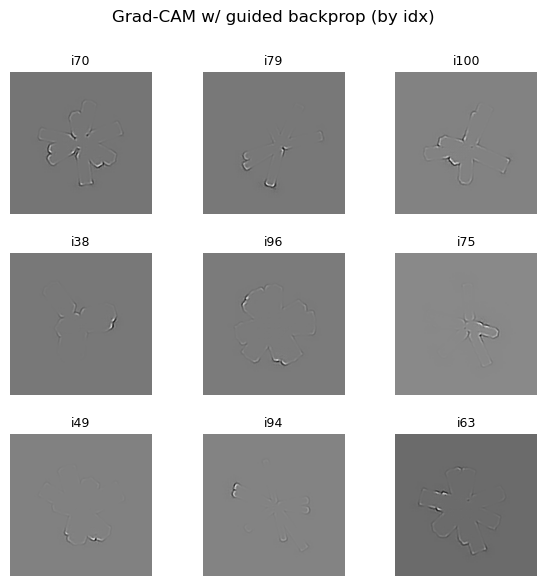

In [21]:
import os, glob, random, math, re
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Directory with saved overlays
cam_outdir = '/home/jko/ice3d-ml-paper/out/xai_outputs/pytorch_grad_cam/gradcam_guided_bp_cls'

# Find files (prefer *_cam_gb.png)
patterns = [
    os.path.join(cam_outdir, "batch*_idx*_cls*_pred_*_cam_gb.png"),
    os.path.join(cam_outdir, "batch*_idx*_cls*_pred_*.png"),
]

paths = []
for p in patterns:
    hit = glob.glob(p)
    if hit:
        paths = hit
        break
paths = sorted(paths)
if not paths:
    raise FileNotFoundError(f"No overlays found in {cam_outdir}")

# Parse only (batch, idx, cls) from filename
rx = re.compile(r"^batch(\d+)_idx(\d+)_cls(\d+)_pred_")
def parse_meta(path):
    base = os.path.basename(path)
    m = rx.match(base)
    if not m:
        return None
    b, i, c = m.groups()
    return {"batch": int(b), "idx": int(i), "cls": int(c)}

# Keep one path per (batch, idx)
by_idx = {}  # (batch, idx) -> path
for p in paths:
    meta = parse_meta(p)
    if not meta:
        continue
    key = (meta["batch"], meta["idx"])
    # If multiple per idx exist, keep the first (or replace with any rule you prefer)
    by_idx.setdefault(key, p)

pairs = list(by_idx.keys())
if not pairs:
    raise RuntimeError("No (batch, idx) images parsed.")

# Sample K indices
K = min(9, len(pairs))
random.seed(0)
sample_pairs = random.sample(pairs, k=K)

# Plot a single grid, titles show only idx
cols = 3
rows = math.ceil(K / cols)
fig, axes = plt.subplots(rows, cols, figsize=(2.0*cols, 2.0*rows))
axes = np.array(axes).reshape(-1)

for ax, (b, i) in zip(axes, sample_pairs):
    path = by_idx[(b, i)]
    with Image.open(path) as im:
        img = np.asarray(im.convert("RGB"))
    ax.imshow(img)
    ax.set_title(f"i{i:02d}", fontsize=9)  # only idx label
    ax.axis("off")

for ax in axes[K:]:
    ax.axis("off")

fig.suptitle("Grad-CAM w/ guided backprop (by idx)", fontsize=12)
plt.tight_layout()
plot_dir = '/home/jko/ice3d-ml-paper/figs/gradcam'
os.makedirs(plot_dir, exist_ok=True)
savepath = os.path.join(plot_dir, "gradcam_grid_nb.png")
fig.savefig(savepath, dpi=300, bbox_inches="tight")
plt.show()

# Scratch

In [ ]:
# ---------------------------
# Grad-CAM extraction on validation set
# ---------------------------

# Output directory
base_dir = './out'
savedir = os.path.join(base_dir, "xai_outputs")
cam_outdir = os.path.join(savedir, "cams_val_gradcam")
os.makedirs(cam_outdir, exist_ok=True)

def denorm(img: torch.Tensor, mean=None, std=None) -> torch.Tensor:
    """
    Invert torchvision.transforms.Normalize with mean=[0.5]*C, std=[1.0]*C.
    img: Tensor [C,H,W] in normalized space.
    mean/std: per-channel sequences; defaults to [0.5]*C and [1.0]*C.
    """
    C = img.shape[0]
    if mean is None:
        mean = [0.5] * C
    if std is None:
        std = [1.0] * C
    mean_t = torch.as_tensor(mean, dtype=img.dtype, device=img.device).view(-1, 1, 1)
    std_t = torch.as_tensor(std, dtype=img.dtype, device=img.device).view(-1, 1, 1)
    out = img * std_t + mean_t
    return out.clamp(0.0, 1.0)

val_loader = dm.val_dataloader()
out_names = ["rho_eff", "sa_eff"]  # indices 0 and 1

def ensure_2d_cam(cam) -> torch.Tensor:
    # Accepts Tensor or ndarray from torchcam and returns [H,W] Tensor
    if isinstance(cam, np.ndarray):
        cam = torch.from_numpy(cam)
    cam = cam.detach().cpu().float()
    if cam.ndim == 2:
        return cam
    if cam.ndim == 3:
        # Fold any channel-like dim and average to a single map
        # Works for [C,H,W] or [H,W,C]
        if cam.shape[0] not in (cam.shape[-2], cam.shape[-1]):  # likely [C,H,W]
            cam = cam.mean(dim=0)
        else:  # likely [H,W,C]
            cam = cam.mean(dim=-1)
        return cam
    if cam.ndim > 3:
        cam = cam.view(-1, cam.shape[-2], cam.shape[-1]).mean(dim=0)
        return cam
    if cam.ndim == 1:
        side = int(cam.numel() ** 0.5)
        return cam[: side * side].view(side, side)
    return cam

# Prefer the last block or its last conv. For your wrapper, use the string path:
target_layer = "resnet.layer4.1.conv2"  # or simply "resnet.layer4"

with SmoothGradCAMpp(model, target_layer=target_layer) as cam_extractor:
    for bidx, (features, targets) in enumerate(val_loader):
        features = features.to(device).requires_grad_(True)
        B, C, H, W = features.shape

        for out_idx, out_name in enumerate(out_names):
            model.zero_grad(set_to_none=True)
            scores = model(features)  # [B,2]

            # Get CAMs; torchcam returns a list (one per image)
            cams = cam_extractor(class_idx=out_idx, scores=scores)

            for i, cam_raw in enumerate(cams):
                cam = ensure_2d_cam(cam_raw)

                # ReLU and normalize
                cam = torch.relu(cam)
                cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-12)

                # Upsample to input size
                cam_up = F.interpolate(
                    cam.unsqueeze(0).unsqueeze(0), size=(H, W),
                    mode='bilinear', align_corners=False
                )[0, 0]

                # Prepare the visualization image (denorm, then to 3-channel)
                img = denorm(features[i].detach().cpu(), mean=[0.5]*C, std=[1.0]*C)
                if C == 1:
                    img_vis = img.repeat(3, 1, 1)
                elif C == 2:
                    img_vis = torch.cat([img, img[:1]], dim=0)
                else:
                    img_vis = img

                pil_img = to_pil_image(img_vis)
                pil_cam = Image.fromarray((cam_up.numpy() * 255).astype(np.uint8), mode='L')
                overlay = overlay_mask(pil_img, pil_cam, alpha=0.45, colormap='magma')

                base = f"val_b{bidx:04d}_i{i:02d}_{out_name}"
                overlay.save(os.path.join(cam_outdir, base + "_gradcam.png"))
                np.save(os.path.join(cam_outdir, base + "_gradcam.npy"), cam_up.numpy())

            if features.grad is not None:
                features.grad.zero_()
            model.zero_grad(set_to_none=True)

In [ ]:
# loader = your DataLoader
num_samples = len(val_loader.dataset)     # total samples
num_batches = len(val_loader)             # total batches
print(num_samples, num_batches)

In [ ]:
# # Enable gradients (required for CAM)
# model.eval()
# model.zero_grad(set_to_none=True)

# with torch.set_grad_enabled(True):
#     for bidx, (features, targets) in enumerate(val_loader):
#         features = features.to(device)  # [B, C, H, W]

#         # Compute CAMs per-output head (recompute scores each time to avoid double-backward)
#         for out_idx, out_name in enumerate(out_names):
#             model.zero_grad(set_to_none=True)
#             scores = model(features)  # fresh graph per output head: [B, 2]

#             cams = cam_extractor(class_idx=out_idx, scores=scores)  # list[Tensors], len=B

#             for i, cam in enumerate(cams):
#                 # cam can be [H,W], [1,H,W], [C,H,W]; make it [H,W]
#                 cam = cam.detach().cpu().float().squeeze()
#                 if cam.ndim == 3:
#                     # reduce any channel dim
#                     sizes = list(cam.shape)
#                     if sizes[0] <= 4:
#                         cam = cam.mean(dim=0)
#                     elif sizes[-1] <= 4:
#                         cam = cam.mean(dim=-1)
#                     else:
#                         cam = cam.mean(dim=0)
#                 elif cam.ndim == 1:
#                     side = int(cam.numel() ** 0.5)
#                     cam = cam[: side * side].view(side, side)

#                 # Normalize CAM to [0,1]
#                 cmin, cmax = float(cam.min()), float(cam.max())
#                 cam = (cam - cmin) / (cmax - cmin + 1e-12)

#                 # Prepare input image for overlay: denorm -> 3-channel
#                 img = features[i].detach().cpu()  # [C,H,W], normalized
#                 img = denorm(img, mean=[0.5]*img.shape[0], std=[1.0]*img.shape[0])

#                 if img.shape[0] == 1:
#                     img_vis = img.repeat(3, 1, 1)
#                 elif img.shape[0] == 2:
#                     img_vis = torch.cat([img, img[:1]], dim=0)
#                 else:
#                     img_vis = img

#                 # Build overlay
#                 pil_img = to_pil_image(img_vis)
#                 pil_cam = Image.fromarray((cam.numpy() * 255).astype(np.uint8), mode='L')
#                 overlay = overlay_mask(pil_img, pil_cam, alpha=0.5, colormap='jet')

#                 # Save overlay and raw CAM
#                 base = f"val_b{bidx:04d}_i{i:02d}_{out_name}"
#                 overlay.save(os.path.join(cam_outdir, base + "_gradcam.png"))
#                 np.save(os.path.join(cam_outdir, base + "_gradcam.npy"), cam.numpy())

In [ ]:
# Visualize samples of the activation map overlays
import os
import glob
import random
from PIL import Image
import matplotlib.pyplot as plt

# Optional: filter by output head ("rho_eff" or "sa_eff"); set to None to mix both
out_filter = 'rho_eff'  # or "rho_eff" or "sa_eff"

# Collect saved overlays
pattern = "*_gradcam.png" if out_filter is None else f"*_{out_filter}_gradcam.png"
overlay_paths = sorted(glob.glob(os.path.join(cam_outdir, pattern)))
if not overlay_paths:
    raise FileNotFoundError(f"No overlays found in {cam_outdir} with pattern {pattern}")

# Sample up to 25 overlays
k = min(25, len(overlay_paths))
sample_paths = random.sample(overlay_paths, k=k)

# Plot 5x5 grid
rows, cols = 5, 5
fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
axes = axes.ravel()

for ax, path in zip(axes, sample_paths):
    img = Image.open(path).convert("RGB")
    # Title from filename suffix: val_b####_i##_rho_eff_gradcam.png -> rho_eff
    base = os.path.basename(path)
    parts = base.split("_")
    title = parts[-2] if len(parts) >= 2 else base
    ax.imshow(img)
    ax.set_title(title, fontsize=8)
    ax.axis("off")

# Hide any unused subplots
for ax in axes[len(sample_paths):]:
    ax.axis("off")

plt.tight_layout()
plt.show()